In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [2]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/fusiontomo/Repos/diffusion_tomography


missing keys: 0
unexpected keys: 0
Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy
0.0 1.0 (100, 4800)


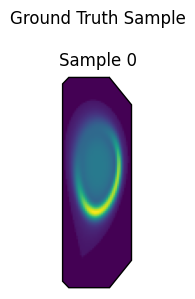

In [3]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

sample_idx = 9 #122, 2 , 9, 12
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

# select samples to be used for normalization procedure
samples_idxs = np.arange(0,1000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# load forward model
A_path = Path("forward_model/forward_model_sxr_full_geometry.npy")
A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T



show_samples(x_gt, title="Ground Truth Sample")

### diffusion

0.0 1.0 (100, 4800)
A_tomo: (100, 4800)


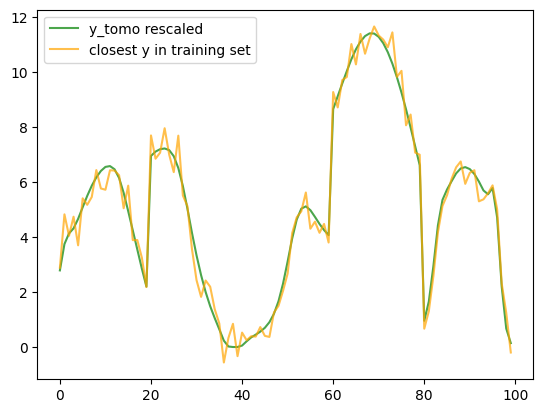

sigma_y_tomo_rescaled: 0.5


In [4]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))


sigma_y_tomo = 0.5
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)
plt.plot((A_tomo @ x_gt.flatten()).cpu().numpy(), label="y_tomo rescaled", color='g', alpha=0.7)
plt.plot(y_tomo.cpu().numpy(), label="closest y in training set", color='orange', alpha=0.7)
plt.legend()
plt.show()

normalize_tomo_data = False
if normalize_tomo_data:
    scaling_factor_diffusion = 1/100
    y_tomo /= scaling_factor_diffusion # normalize data to 1
    sigma_y_tomo /= scaling_factor_diffusion
    x_gt /= scaling_factor_diffusion
else:
    scaling_factor_diffusion = 1.0

# rescale data to closest training sample scale
scale_to_opt = False
# Compute normalization coefficient alpha to match the distribution of y_tomo with the training data distribution
if scale_to_opt:
    # Compute normalization coefficient alpha to match the distribution of y_tomo with the training data distribution
    alpha, y_closest = compute_normalization_coefficient(y_tomo.reshape(1, -1), y_tomo_train)
    print(f"Computed normalization coefficient alpha: {alpha:.4f}")
    print("scaling_factor_diffusion:", 1/scaling_factor_diffusion)
else:
    alpha = 1.0
y_tomo_rescaled = y_tomo / alpha
sigma_y_tomo_rescaled = sigma_y_tomo / alpha
print("sigma_y_tomo_rescaled:", sigma_y_tomo_rescaled)

# plot profile found by scaling
# plt.plot(y_tomo.cpu().numpy(), label="y_tomo", color='r')
# plt.plot((A_tomo @ x_gt.flatten()).cpu().numpy(), label="A @ x_gt", color='b', alpha=0.7)
# plt.plot(y_tomo_rescaled.cpu().numpy(), label="y_tomo rescaled", color='g', alpha=0.7)
# plt.plot(y_closest.cpu().numpy(), label="closest y in training set", color='orange', alpha=0.7)
# plt.legend()
# plt.show()

(np.float64(-0.75), np.float64(40.75), np.float64(-0.75), np.float64(120.75))

<Figure size 300x300 with 0 Axes>

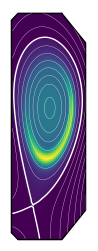

In [5]:
psis_path = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/psis_coarse.npy")
psi = np.load(psis_path)[sample_idx]

plt.figure(figsize=(3,3))
tomo_plots.plot_profile(np.array(x_gt[0,0].cpu()), tcv_plot_clip=True,
                                contour_image=psi, cmap="viridis", ax=None,
                                colorbar=False, contour_color="w",
                                aspect=None, lcfs_width=1, lwidth=0.2)

plt.savefig('results_images/posterior_sampling_process/figs/ground_truth.eps', format='eps', bbox_inches="tight")

plt.axis('off')

(np.float64(-3.0), np.float64(50.0), np.float64(-10.5), np.float64(130.0))

<Figure size 300x300 with 0 Axes>

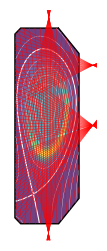

In [6]:
plt.figure(figsize=(3,3))
ground_truth = np.array(x_gt[0,0].cpu())
# plot ground truth, superposing the sxr LoS
patch = tomo_plots.plot_profile(ground_truth, levels=12, tcv_plot_clip=True, ax=None, contour_image=psi, alpha_imshow=0.75)

# read los params
params = np.load("results_images/posterior_sampling_process/sxr_LoS_params.npy")
r = np.linspace(0, ground_truth.shape[0], 10)
center = np.array(ground_truth.shape, dtype=int) / 2
Lr, Lz = 0.5, 1.5
h = Lz / ground_truth.shape[0]

# plot ground truth, superposing the sxr LoS
from matplotlib.path import Path
from matplotlib.patches import PathPatch

# Variant patches: same vessel outline as `patch`, but with one side opened up
# so specific LoS groups aren't clipped where they're meant to extend past the vessel.
_v0 = patch.get_path().vertices
_codes = patch.get_path().codes
_x_max, _y_max, _y_min = _v0[:, 0].max(), _v0[:, 1].max(), _v0[:, 1].min()

# patch1: top opened (i<20, top vertical fan)
_v = _v0.copy()
_v[_v[:, 1] > _y_max - 10, 1] = 300
patch1 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch1)

# patch2: right opened (60<=i<80, horizontal fan extending past the outer wall)
_v = _v0.copy()
_v[_v[:, 0] > _x_max - 10, 0] = 300
patch2 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch2)

# patch3: bottom opened (80<=i<100, divertor fan extending below the vessel)
_v = _v0.copy()
_v[_v[:, 1] < _y_min + 10, 1] = -300
patch3 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch3)

r_vert = np.linspace(0., 40.4, 4000)
r_horiz = np.linspace(0., 52.4, 4000)
r_div = np.linspace(0., 47.4, 4000)
center = np.array([120, 41], dtype=int) / 2
Lr, Lz = 0.511, 1.5
h = Lz / 120
for i in range(params.shape[0]):
    if np.isclose(np.tan(params[i, 1]), 0, atol=1e-6):
        lc = plt.vlines(center[1] + params[i, 0], 0, Lz, "r", linewidth=0.3)
        lc.set_clip_path(patch)
    else:
        p = params[i, 0]
        theta = params[i, 1]
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        if i<20:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            lines = plt.plot(r_vert[(y>0.) & (y<130)], y[(y>0.) & (y<130)], "r", linewidth=0.3)
            clip = patch1
        elif i<60:
            y = center[0] + p / h / np.sin(theta) - (r_horiz - center[1]) / np.tan(theta)
            lines = plt.plot(r_horiz[(y>0.4) & (y<119.6)], y[(y>0.4) & (y<119.6)], "r", linewidth=0.3)
            clip = patch2
        elif i<80:
            y = center[0] + p / h / np.sin(theta) - (r_horiz - center[1]) / np.tan(theta)
            lines = plt.plot(r_horiz[:], y[:], "r", linewidth=0.3)
            clip = patch2
        elif i<100:
            y = center[0] + p / h / np.sin(theta) - (r_div - center[1]) / np.tan(theta)
            lines = plt.plot(r_div[ (y>-10.) & (y<119.6)], y[ (y>-10.) & (y<119.6)], "r", linewidth=0.3)
            clip = patch3
        else:
            lines = plt.plot(r_vert, y, "r", linewidth=0.4)
            clip = patch
        for ln in lines:
            ln.set_clip_path(clip)
# plt.xlim([-0.75, 41.75])
# plt.ylim([-0.75, round(Lz / h)+0.75])
plt.xlim([-3, 50])
plt.ylim([-10.5, 130])

plt.savefig('results_images/posterior_sampling_process/figs/sxr_LoS_configuration.eps', format='eps', bbox_inches="tight")


plt.axis('off')

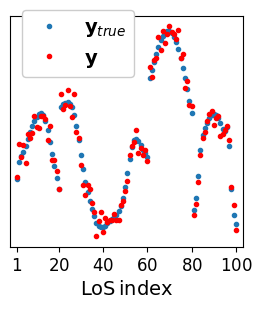

In [7]:
plt.figure(figsize=(3,3))
# plot tomographic data
plt.plot(np.arange(1, 101), (A_tomo @ x_gt.flatten()).cpu().numpy(), '.', label=r"$\mathbf{y}_{true}$")
plt.plot(np.arange(1, 101), y_tomo.cpu().numpy(), 'r.', label=r"$\mathbf{y}$")
plt.xlabel(r"$\mathrm{LoS\,index}$", fontsize=14)
plt.xlim([-2, 103])
plt.tick_params(labelsize=12)
plt.xticks([1, 20,40,60,80,100], [r"$1$", r"$20$", r"$40$", r"$60$", r"$80$", r"$100$"])
plt.xlabel(r"$\mathrm{LoS\,index}$", fontsize=14)
#plt.ylim([-0.04,0.4])
#plt.yticks([0,0.2,0.4], [r"$0$",r"$0.2$",r"$0.4$"])
plt.yticks([])
plt.legend(loc=(0.05,0.735), fontsize=14, framealpha=1)
plt.show()

import pandas as pd
# save (A_tomo @ x_gt.flatten()).cpu().numpy() as "y_true" and y_tomo.cpu().numpy() as "y_noisy" in a dataframe and export to csv
df = pd.DataFrame({"y_true": (A_tomo @ x_gt.flatten()).cpu().numpy(),
    "y_noisy": y_tomo.cpu().numpy()})
df.to_csv("results_images/posterior_sampling_process/figs/sxr_tomo_data.csv", index=False)


In [5]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt
import os
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps


anis_param = 1e-3

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]

g = AnisDiffusionOp(
    dim_shape=(1, H, W),
    alpha=anis_param,
    diff_method_struct_tens="fd",
    freezing_arr=psi,
    sampling=0.0125,
    matrix_based_impl=True,
)

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_)

/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisCoherenceEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:AnisEdgeEnhancingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: ContributionWarning: Plugin `pyxu_diffops.operator:CurvaturePreservingDiffusionOp` loaded.
  warnings.warn(msg, pxw.ContributionWarning)
/home/haouchat/miniconda3/envs/fusion/lib/python3.12/site-packages/pyxu/info/plugin.py:70: Contributio

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

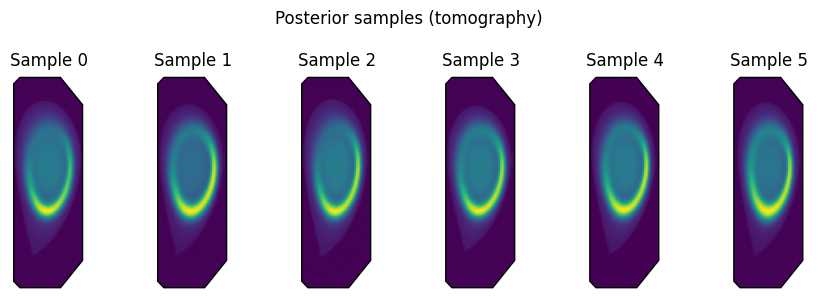

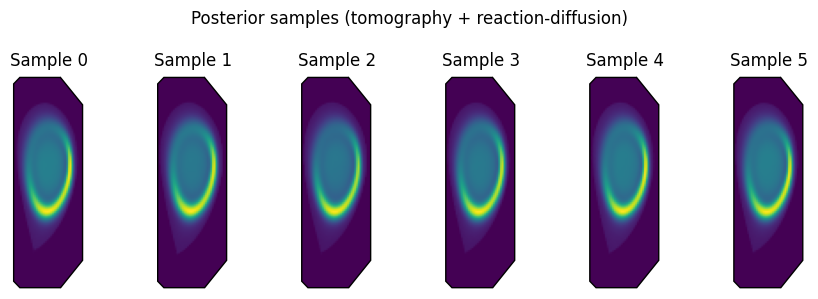

In [6]:
posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo_rescaled,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,#0.6, 0.8
    sigma_y=sigma_y_tomo_rescaled,
    lambda_=100,   # 100, 300 for normalize_data=False
    clip_range=None,
    reaction_diffusion_op=None,
    lambda_rd=1e-15,
)

posterior_tomo_rdd, tomo_residuals_rdd, diffusion_process_rdd = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.9,
    sigma_y=sigma_y_tomo,
    lambda_=5,  
    clipping_mask=torch.tensor(mask_core, dtype=torch.float32, device=device),
    reaction_diffusion_op = g,
    lambda_rd = 1e-4, #1e-4
)

show_samples(posterior_tomo[:6], title="Posterior samples (tomography)", ncols=6)
show_samples(posterior_tomo_rdd[:6], title="Posterior samples (tomography + reaction-diffusion)", ncols=6)


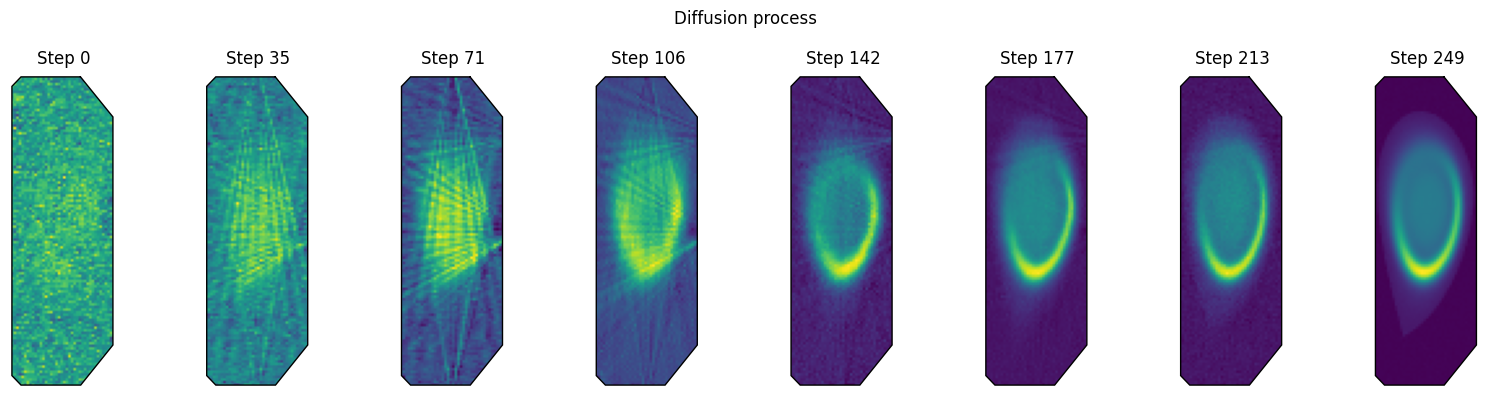

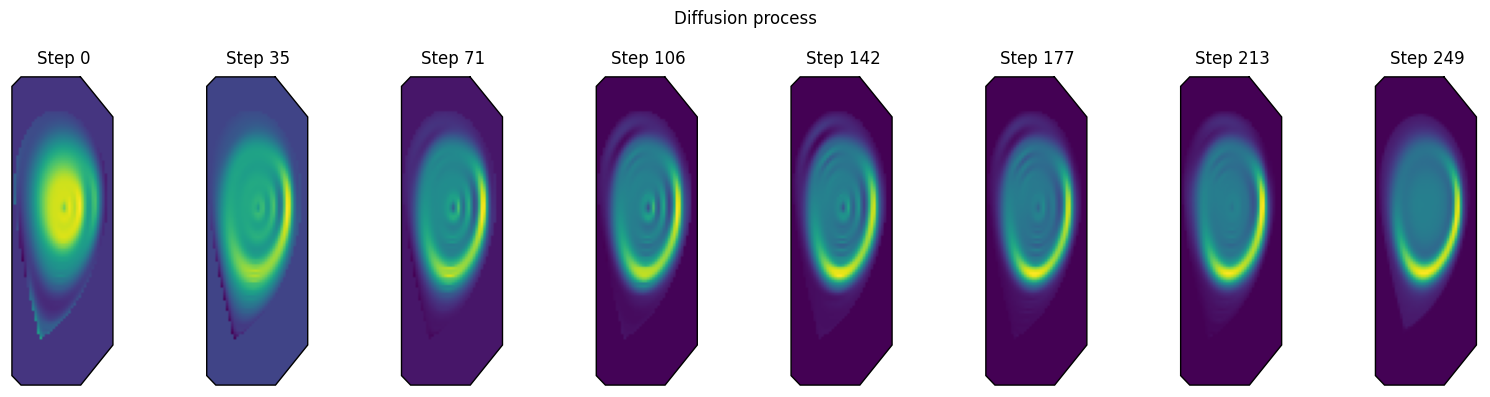

In [7]:
indices = np.linspace(0, len(diffusion_process) - 1, 8, dtype=int)
dp_tensor = torch.stack([diffusion_process[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process",
)

indices = np.linspace(0, len(diffusion_process_rdd) - 1, 8, dtype=int)
dp_tensor = torch.stack([diffusion_process_rdd[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process",
)

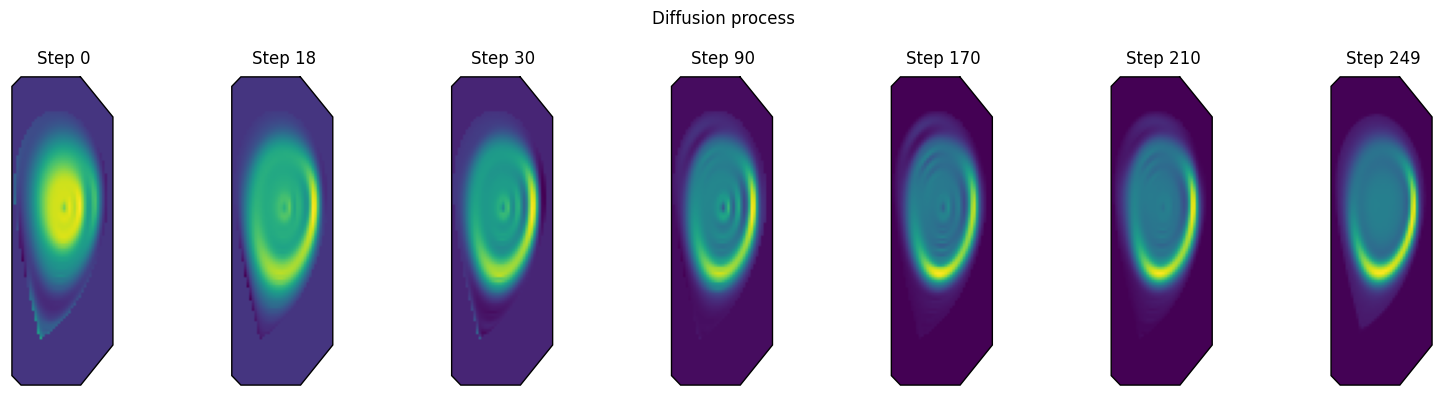

<Figure size 300x300 with 0 Axes>

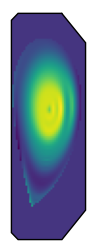

<Figure size 300x300 with 0 Axes>

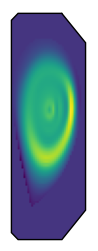

<Figure size 300x300 with 0 Axes>

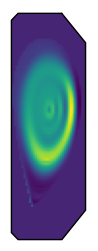

<Figure size 300x300 with 0 Axes>

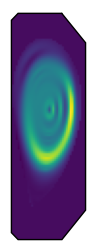

<Figure size 300x300 with 0 Axes>

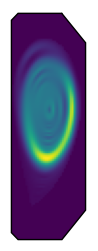

<Figure size 300x300 with 0 Axes>

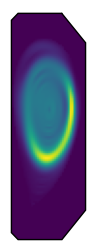

<Figure size 300x300 with 0 Axes>

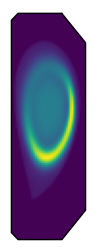

In [42]:
L = len(diffusion_process)
indices = [0, 18, 30, 90, 170, 210, 249]
dp_tensor = torch.stack([diffusion_process_rdd[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=len(indices),
    figsize=(16, 4),
    title="Diffusion process", 
)

#save each individual eps figure
for i, idx in enumerate(indices):
    plt.figure(figsize=(3,3))
    tomo_plots.plot_profile(np.array(dp_tensor[i][0].cpu()), tcv_plot_clip=True,
                                contour_image=None, cmap="viridis", ax=None,
                                colorbar=False, contour_color="w",
                                aspect=None, lcfs_width=1, lwidth=0.2)
    plt.axis('off')
    plt.savefig(f'results_images/posterior_sampling_process/figs/diffusion_process_sxr_step_{idx}_{i}.eps', format='eps', bbox_inches="tight")

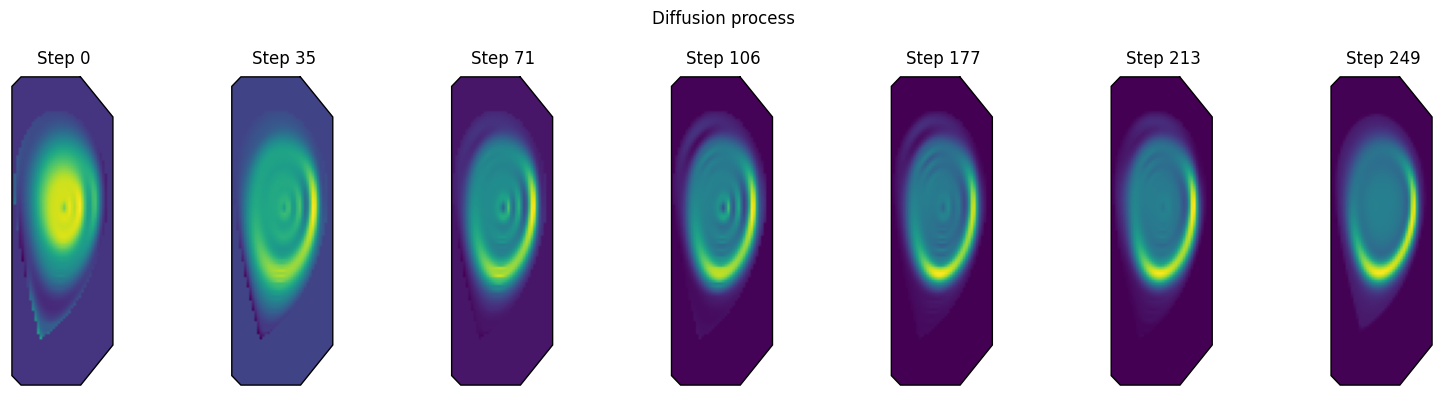

<Figure size 300x300 with 0 Axes>

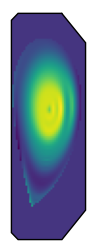

<Figure size 300x300 with 0 Axes>

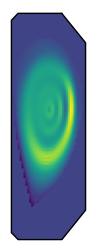

<Figure size 300x300 with 0 Axes>

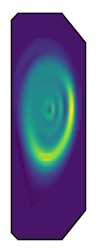

<Figure size 300x300 with 0 Axes>

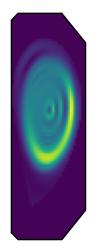

<Figure size 300x300 with 0 Axes>

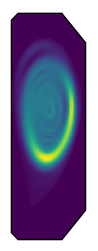

<Figure size 300x300 with 0 Axes>

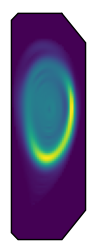

<Figure size 300x300 with 0 Axes>

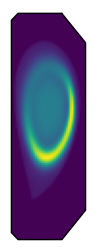

In [ ]:
L = len(diffusion_process)
indices = [0, 35, 71, 106, 177, 213, 249]
dp_tensor = torch.stack([diffusion_process_rdd[i] for i in indices])
show_samples(
    dp_tensor,
    titles=[f"Step {i}" for i in indices],
    ncols=len(indices),
    figsize=(16, 4),
    title="Diffusion process", 
)

#save each individual eps figure
for i, idx in enumerate(indices):
    plt.figure(figsize=(3,3))
    tomo_plots.plot_profile(np.array(dp_tensor[i][0].cpu()), tcv_plot_clip=True,
                                contour_image=None, cmap="viridis", ax=None,
                                colorbar=False, contour_color="w",
                                aspect=None, lcfs_width=1, lwidth=0.2)
    plt.axis('off')
    plt.savefig(f'results_images/posterior_sampling_process/figs/diffrd_process_sxr_step_{idx}_{i}.eps', format='eps', bbox_inches="tight")